In [1]:
import qiskit

## **Circuit Optimization: Gate Fusion & Depth Reduction**

1. **Theory: Trimming the Quantum Fat**

When we write quantum circuits, we often write them in a way that makes logical sense to humans. However, this is rarely the most efficient way for a quantum computer to run them.

Why do we need optimization?
Because of Noise. Every gate takes time to execute. CNOT (CX) gates are especially slow and noisy. The longer your circuit takes, the more time the qubits have to lose their information (decoherence).

Key Optimization Concepts:

Circuit Depth: This is the "critical path" or the longest sequence of gates in your circuit. A depth of 10 means 10 layers of operations happen one after another. Lower depth = less noise.

Gate Fusion: Sometimes gates cancel each other out.

Example: Two X-gates in a row ($X \to X$) do nothing. They can be deleted.

Example: Two small rotations ($R_Z(0.2) \to R_Z(0.3)$) can be fused into one ($R_Z(0.5)$).

CX Count Optimization: CNOT gates are the most "expensive" gates. Optimizers try to use mathematical tricks to reduce the total number of CX gates needed.

The Transpiler: Qiskit has a built-in compiler called the Transpiler. It translates our human-friendly circuit into a highly optimized, machine-friendly circuit.

2. **Code: Optimizing Grover's Circuit on a 5-Qubit Backend**

We will build a simple 2-qubit Grover's Search circuit. Then, we will ask the Qiskit Transpiler to optimize it and map it onto a restricted 5-qubit backend (like a real IBM machine where not all qubits are connected to each other).



--- Original Unoptimized Circuit ---
Original Depth: 10
Original Gate Counts: OrderedDict({'h': 8, 'z': 2, 'x': 2, 'cx': 1, 'cz': 1})

--- Optimized Circuit (Mapped to 5-Qubit backend) ---
Optimized Depth: 5
Optimized Gate Counts: OrderedDict({'h': 3, 'cx': 1, 'u2': 1, 'z': 1, 'cz': 1})


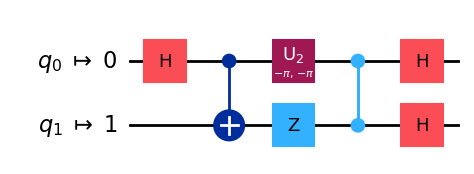

In [2]:

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_circuit_layout

# --- Step 1: Build the Unoptimized Circuit (2-Qubit Grover for |11>) ---
qc = QuantumCircuit(2)

# 1. Initialization
qc.h([0, 1])

# 2. Oracle (Marks |11> with a negative phase using a CZ gate)
qc.h(1)
qc.cx(0, 1) # CX gate
qc.h(1)

# 3. Diffuser (Amplifies the marked state)
qc.h([0, 1])
qc.z([0, 1])
qc.cz(0, 1) # Another CZ (requires CX under the hood)
qc.h([0, 1])

# Let's intentionally add some bad, redundant gates to see the optimizer work!
qc.x(0)
qc.x(0) # These two X gates should cancel out

print("--- Original Unoptimized Circuit ---")
print(f"Original Depth: {qc.depth()}")
print(f"Original Gate Counts: {qc.count_ops()}")
# You will see 'x': 2, 'h': 6, 'cx': 1, 'cz': 1, 'z': 2

# --- Step 2: Define a 5-Qubit Backend (Linear Topology) ---
# Imagine a 5-qubit line: 0-1-2-3-4
# Qubit 0 can only talk to 1. Qubit 1 can talk to 0 and 2, etc.
linear_5q_map = [[0,1], [1,0], [1,2], [2,1], [2,3], [3,2], [3,4], [4,3]]

# --- Step 3: The Magic (Transpilation/Optimization) ---
# optimization_level=3 is the highest effort Qiskit will make to reduce gates
optimized_qc = transpile(qc, 
                         coupling_map=linear_5q_map, 
                         initial_layout=[0, 1], # Put our 2 qubits on physical spots 0 and 1
                         optimization_level=3)

print("\n--- Optimized Circuit (Mapped to 5-Qubit backend) ---")
print(f"Optimized Depth: {optimized_qc.depth()}")
print(f"Optimized Gate Counts: {optimized_qc.count_ops()}")

# Notice that the two 'x' gates completely disappeared (Gate Fusion!)
# Notice that 'h', 'z', and 'cz' were broken down into standard backend gates (like 'rz', 'sx', 'cx')

# --- Visualize ---
display(optimized_qc.draw('mpl', idle_wires=False))


**3. Exercises (Homework)**

Exercise 1: The Impact of Optimization Levels

Goal: Understand how hard Qiskit works at different levels.

Task: Change optimization_level=3 in the code above to optimization_level=0 (which means do not optimize, just translate).

Observation: Check the Optimized Depth and Gate Counts. You will see that level 0 leaves the redundant X-gates in the circuit, resulting in a deeper, worse circuit! Qiskit supports levels 0, 1, 2, and 3.

**Exercise 2: The Swapping Problem (Routing)**

Goal: See what happens when qubits are not physically connected.

Task: In the transpile function, change initial_layout=[0, 1] to initial_layout=[0, 4].

Why? In our 5-qubit map, Qubit 0 and Qubit 4 are at opposite ends of the line. They cannot do a CNOT directly!

Observation: Look at the optimized circuit now. The depth and CX count will explode! Qiskit will automatically add SWAP gates (which cost 3 CNOTs each) to physically move the quantum information across the chip so they can interact. This proves why choosing the right physical qubits is vital!


## **Circuit Optimization: The Gate Fusion Deep Dive**

1. Theory: Who Can Fuse and Who Cannot?

What is Gate Fusion?
Gate fusion is the process of combining two or more quantum gates into a single gate, or deleting them entirely if they cancel each other out. This reduces the Circuit Depth and minimizes hardware noise.

Think of it like basic math: if you add 2 and then add 3, the compiler just fuses it to "add 5". If you add 2 and subtract 2, the compiler just deletes the steps.

## **The "Can Fuse" List**

These gates will fuse if they are right next to each other on the same qubit.

The Self-Inverses (Annihilation): If a gate is its own opposite, doing it *twice* does nothing (Identity). The compiler will delete them.

$X \to X$ = Nothing

$Y \to Y$ = Nothing

$Z \to Z$ = Nothing

$H \to H$ = Nothing

$CNOT \to CNOT$ = Nothing (if applied to the exact same control and target)

The Additive Rotations (Combination): If you rotate around the same axis multiple times, they fuse into one bigger rotation.

$R_X(\theta_1) \to R_X(\theta_2) = R_X(\theta_1 + \theta_2)$

$R_Z(\pi/2) \to R_Z(\pi/2) = R_Z(\pi)$ (which is a Z gate!)

$S \to S = Z$ (Since S is a 90-degree Z-rotation, two S gates make a 180-degree Z-rotation).

### ***The "Cannot Fuse" List***

When will the compiler refuse to fuse gates?

***Different Axes (Usually):*** If you apply an $X$ gate followed by an $H$ gate, they do completely different geometric rotations. The transpiler will not delete them (though at optimization level 3, it might combine them into one massive, complex $U$-gate, but they don't cleanly cancel).

***Blocked by Entanglement (The Golden Rule):*** Two gates on the same qubit cannot fuse if there is an active CNOT gate between them that touches that qubit.

***Example:*** $X(0) \to CNOT(0, 1) \to X(0)$. The X gates cannot cancel because the CNOT in the middle relied on the state of Qubit 0 after the first X gate.

Blocked by Barriers: Qiskit has a barrier() command. Its entire job is to tell the transpiler, "Do NOT fuse anything across this line!"




--- Original Unoptimized Circuit ---
Depth: 6


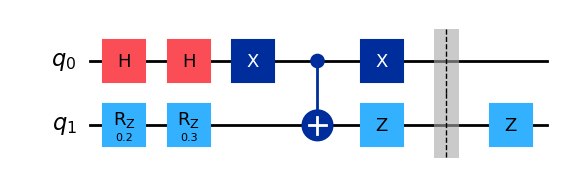


--- Optimized Circuit (After Gate Fusion) ---
Depth: 4


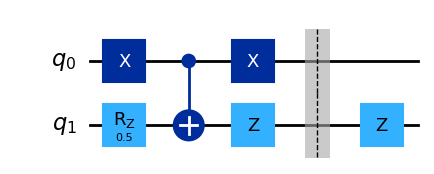

In [3]:
from qiskit import QuantumCircuit, transpile

# --- Step 1: Write a inefficient circuit ---
qc = QuantumCircuit(2)

# 1. Annihilation (These should disappear)
qc.h(0)
qc.h(0) 

# 2. Combination (These should become one RZ gate)
qc.rz(0.2, 1)
qc.rz(0.3, 1)

# 3. Blocked by Entanglement (These X gates CANNOT fuse)
qc.x(0)
qc.cx(0, 1)
qc.x(0)

# 4. Blocked by Barrier (These Z gates CANNOT fuse because of the wall)
qc.z(1)
qc.barrier()
qc.z(1)

print("--- Original Unoptimized Circuit ---")
print(f"Depth: {qc.depth()}")
display(qc.draw('mpl'))

# --- Step 2: Transpile (Optimize) ---
# optimization_level=2 is smart enough to do all basic fusions
optimized_qc = transpile(qc, optimization_level=2)

print("\n--- Optimized Circuit (After Gate Fusion) ---")
print(f"Depth: {optimized_qc.depth()}")
display(optimized_qc.draw('mpl'))




What you will see when you run this:

The two H gates on Qubit 0 completely vanish.

The two RZ gates on Qubit 1 merge into a single $U$-gate or $R_Z(0.5)$ gate.

The two X gates surrounding the CX gate remain exactly where they are.

The two Z gates surrounding the barrier remain exactly where they are.

***3. Exercises (Homework)***

Exercise 1: The S-Gate Secret

Goal: Prove that two S-gates equal a Z-gate.

Task: Create a 1-qubit circuit. Apply two S-gates in a row: qc.s(0) then qc.s(0).

Action: Pass it through transpile(qc, optimization_level=2).

Observation: Draw the optimized circuit. You should see that Qiskit replaced your two S-gates with a single Z gate (or a phase gate equivalent to Z).

***Exercise 2: CNOT Annihilation***

Goal: Prove that CNOT is its own inverse.

Task: Create a 2-qubit circuit. Apply a CNOT, then an X gate to qubit 1, then another CNOT.
qc.cx(0,1) -> qc.x(1) -> qc.cx(0,1).

Action: Transpile this with optimization_level=3.

Observation: Does the transpiler delete the CNOTs? (Spoiler: It won't! Because the X-gate in the middle changes the target, breaking the annihilation rule. Try deleting the X-gate and watch the CNOTs vanish!)
